# Diplomatura en IA - UP 
### Practico N°2 - Jun26
### Alumno: Gonzalez Marta Elizabeth 
### Notebook 03 - Preprocesamiento -

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/processed/02_dataset_eda.csv")



In [3]:
print(df.shape)
df.head()

(50000, 27)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1
3,3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,4.166667,2.500000,4.000000,13.416667,10.583333,1.875000,9.416667,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0
4,4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,5.000000,3.083333,3.333333,7.666667,3.083333,2.583333,4.458333,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   50000 non-null  int64  
 1   gender               50000 non-null  object 
 2   age                  50000 non-null  int64  
 3   height(cm)           50000 non-null  int64  
 4   weight(kg)           50000 non-null  int64  
 5   waist(cm)            50000 non-null  float64
 6   eyesight(left)       50000 non-null  float64
 7   eyesight(right)      50000 non-null  float64
 8   hearing(left)        50000 non-null  float64
 9   hearing(right)       50000 non-null  float64
 10  systolic             50000 non-null  float64
 11  relaxation           50000 non-null  float64
 12  fasting blood sugar  50000 non-null  float64
 13  Cholesterol          50000 non-null  float64
 14  triglyceride         50000 non-null  float64
 15  HDL                  50000 non-null 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,50000.0,26284.994580,16015.070567,0.000000,12499.750000,24999.500000,40034.250000,55690.000000
age,50000.0,44.189300,12.090086,20.000000,40.000000,40.000000,55.000000,85.000000
height(cm),50000.0,164.652000,9.208778,130.000000,160.000000,165.000000,170.000000,190.000000
weight(kg),50000.0,65.878700,12.831355,30.000000,55.000000,65.000000,75.000000,135.000000
waist(cm),50000.0,3.414852,0.386765,2.125000,3.166667,3.416667,3.666667,5.375000
eyesight(left),50000.0,0.028446,0.024007,0.000694,0.005556,0.041667,0.043056,0.381250
eyesight(right),50000.0,0.028304,0.024216,0.000694,0.005556,0.041667,0.043056,0.381250
hearing(left),50000.0,0.042736,0.006588,0.041667,0.041667,0.041667,0.041667,0.083333
hearing(right),50000.0,0.042758,0.006655,0.041667,0.041667,0.041667,0.041667,0.083333
systolic,50000.0,5.062531,0.570100,2.958333,4.666667,5.000000,5.416667,10.000000


In [6]:
nulos = df.isnull().sum()

nulos[nulos > 0]

Series([], dtype: int64)

In [7]:
print("Cantidad total de nulos:", df.isnull().sum().sum())

Cantidad total de nulos: 0


In [8]:
df.drop(columns=['ID'], inplace=True)

print(df.shape)

(50000, 26)


In [9]:
# Ingeniería de Características - Body Mass Index:

df['BMI'] = (
    df['weight(kg)'] /
    ((df['height(cm)']/100)**2)
)

In [10]:
# Ingeniería de Características -Waist-to-Height Ratio
df['WHR'] = (
    df['waist(cm)'] /
    (df['height(cm)']/100)
)

In [11]:
# Cholesterol / HDL Ratio

df['chol_hdl_ratio'] = (
    df['Cholesterol'] /
    df['HDL']
)

In [12]:
# Triglyceride / HDL Ratio

df['tri_hdl_ratio'] = (
    df['triglyceride'] /
    df['HDL']
)

In [13]:
# Verificación de nuevas variables

df[['BMI',
    'WHR',
    'chol_hdl_ratio',
    'tri_hdl_ratio']].describe()

,BMI,WHR,chol_hdl_ratio,tri_hdl_ratio
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,24.169806,2.075573,3.624974,2.496517
std,3.479942,0.221008,1.070923,1.856053
min,14.268728,1.328125,0.383495,0.123077
25%,21.604938,1.921296,2.861111,1.196078
50%,23.875115,2.060049,3.488889,1.940299
75%,26.122449,2.213542,4.244898,3.210526
max,42.448980,3.310330,52.500000,47.500000


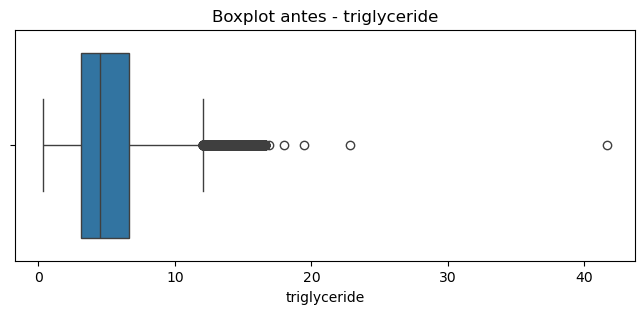

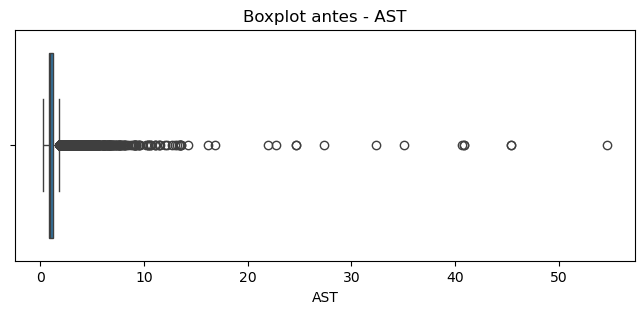

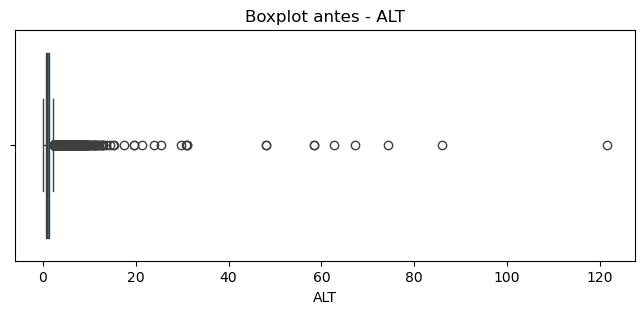

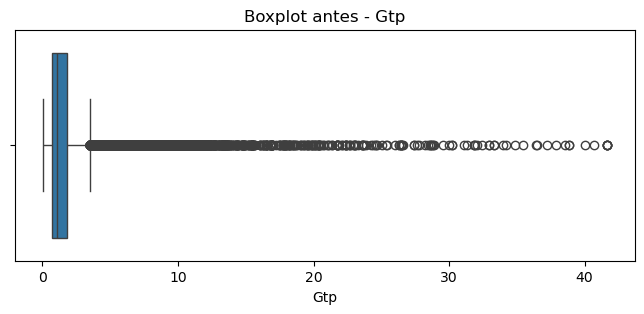

In [14]:
#En el EDA se detectaron valores extremos principalmente en:

#triglyceride
#AST
#ALT
#Gtp

#Dado que son variables clínicas, se utilizará Winsorización (capping) para evitar la pérdida de registros.


variables_outliers = [
    'triglyceride',
    'AST',
    'ALT',
    'Gtp'
]

for col in variables_outliers:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot antes - {col}')
    plt.show()

In [16]:
#Aplicación de Winsorización
#Guardar límites utilizados

limites_outliers = {}

In [17]:
for col in variables_outliers:

    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)

    limites_outliers[col] = {
        'p1': p1,
        'p99': p99
    }

    df[col] = np.where(
        df[col] < p1,
        p1,
        df[col]
    )

    df[col] = np.where(
        df[col] > p99,
        p99,
        df[col]
    )

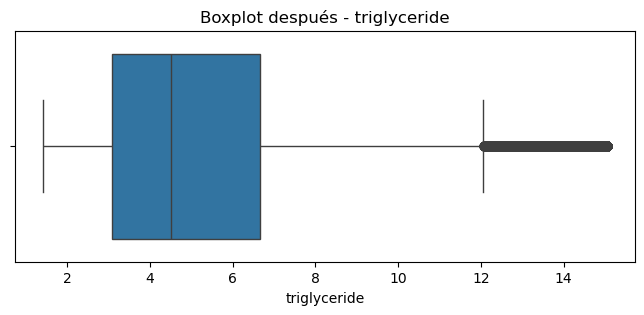

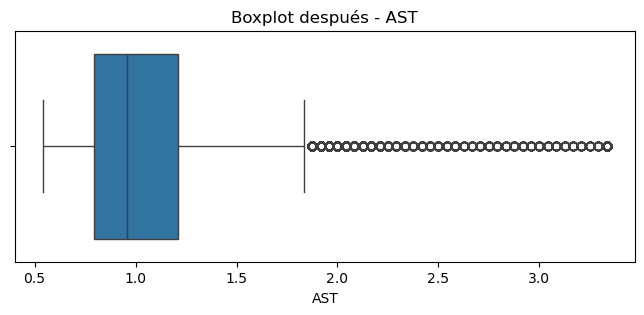

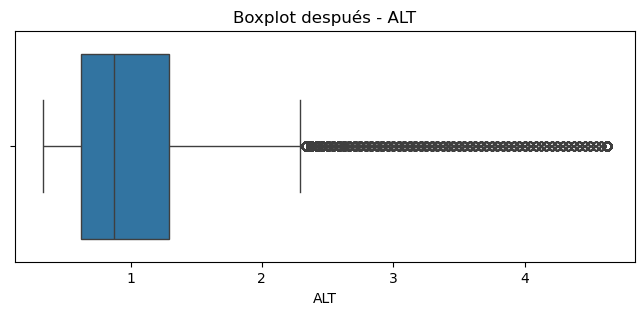

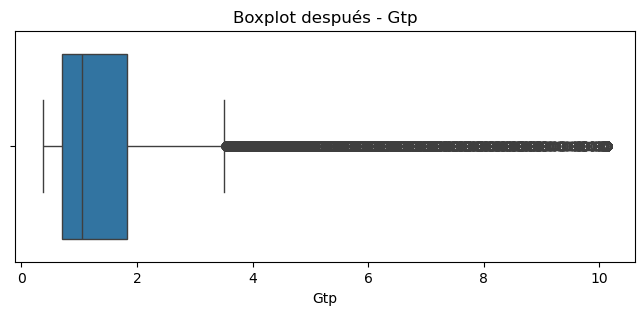

In [18]:
# Visualización posterior

for col in variables_outliers:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot después - {col}')
    plt.show()

In [19]:
#Guardar límites para reutilización

limites_df = pd.DataFrame(limites_outliers).T

limites_df

,p1,p99
triglyceride,1.416667,15.041667
AST,0.541667,3.333333
ALT,0.333333,4.625000
Gtp,0.375000,10.125000


In [20]:
# Verificacion final

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               50000 non-null  object 
 1   age                  50000 non-null  int64  
 2   height(cm)           50000 non-null  int64  
 3   weight(kg)           50000 non-null  int64  
 4   waist(cm)            50000 non-null  float64
 5   eyesight(left)       50000 non-null  float64
 6   eyesight(right)      50000 non-null  float64
 7   hearing(left)        50000 non-null  float64
 8   hearing(right)       50000 non-null  float64
 9   systolic             50000 non-null  float64
 10  relaxation           50000 non-null  float64
 11  fasting blood sugar  50000 non-null  float64
 12  Cholesterol          50000 non-null  float64
 13  triglyceride         50000 non-null  float64
 14  HDL                  50000 non-null  float64
 15  LDL                  50000 non-null 

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.189300,12.090086,20.000000,40.000000,40.000000,55.000000,85.000000
height(cm),50000.0,164.652000,9.208778,130.000000,160.000000,165.000000,170.000000,190.000000
weight(kg),50000.0,65.878700,12.831355,30.000000,55.000000,65.000000,75.000000,135.000000
waist(cm),50000.0,3.414852,0.386765,2.125000,3.166667,3.416667,3.666667,5.375000
eyesight(left),50000.0,0.028446,0.024007,0.000694,0.005556,0.041667,0.043056,0.381250
eyesight(right),50000.0,0.028304,0.024216,0.000694,0.005556,0.041667,0.043056,0.381250
hearing(left),50000.0,0.042736,0.006588,0.041667,0.041667,0.041667,0.041667,0.083333
hearing(right),50000.0,0.042758,0.006655,0.041667,0.041667,0.041667,0.041667,0.083333
systolic,50000.0,5.062531,0.570100,2.958333,4.666667,5.000000,5.416667,10.000000
relaxation,50000.0,3.167326,0.403490,1.666667,2.916667,3.166667,3.416667,6.083333


In [22]:
df.head()

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking,BMI,WHR,chol_hdl_ratio,tri_hdl_ratio
0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0,24.973985,2.178763,2.945205,1.123288
1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0,23.437500,2.109375,4.571429,2.738095
2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1,20.761246,1.960784,4.400000,3.309091
3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,4.166667,2.500000,4.000000,13.416667,10.583333,1.875000,9.416667,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0,25.711662,2.222222,7.155556,5.644444
4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,5.000000,3.083333,3.333333,7.666667,3.083333,2.583333,4.458333,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0,24.973985,2.311828,2.967742,1.193548


In [23]:
# Exportacion para entrenamiento

df.to_csv(
    "../data/processed/03_dataset_preprocesado.csv",
    index=False
)

print("Dataset exportado correctamente")

Dataset exportado correctamente


In [24]:
print('smoking' in df.columns)

True


In [25]:
df.shape

(50000, 30)

In [26]:
df.columns.tolist()

['gender',
 'age',
 'height(cm)',
 'weight(kg)',
 'waist(cm)',
 'eyesight(left)',
 'eyesight(right)',
 'hearing(left)',
 'hearing(right)',
 'systolic',
 'relaxation',
 'fasting blood sugar',
 'Cholesterol',
 'triglyceride',
 'HDL',
 'LDL',
 'hemoglobin',
 'Urine protein',
 'serum creatinine',
 'AST',
 'ALT',
 'Gtp',
 'oral',
 'dental caries',
 'tartar',
 'smoking',
 'BMI',
 'WHR',
 'chol_hdl_ratio',
 'tri_hdl_ratio']

In [27]:
variables_outliers = [
    'triglyceride',
    'AST',
    'ALT',
    'Gtp'
]

limites_outliers = {}

for col in variables_outliers:

    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)

    limites_outliers[col] = {
        'p1': p1,
        'p99': p99
    }

In [28]:
limites_df = pd.DataFrame(limites_outliers).T

limites_df

,p1,p99
triglyceride,1.416667,15.041667
AST,0.541667,3.333333
ALT,0.333333,4.625000
Gtp,0.375000,10.125000


In [29]:
limites_df.to_csv(
    "../data/processed/parametros_outliers.csv"
)